<a href="https://colab.research.google.com/github/pkcastrovasc/citation_graph/blob/main/analise_grafo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instale as dependências necessárias executando esta célula
!pip install algs4 powerlaw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 6.5 MB/s eta 0:00:00


In [2]:
from algs4.digraph import Digraph
from algs4.symbol_digraph import SymbolDigraph

# 1. Leitura do Grafo Original
# Usamos "\t" (Tabulação) porque é assim que as colunas do seu arquivo estão separadas.
sg = SymbolDigraph("grafo.txt", "\t")
digraph = sg.digraph()

# Extração de V e E
V = digraph.V
E = digraph.E
# digraph.adj é uma lista de objetos Bag. Para obter o tamanho, usamos o método .size()
#outdegrees = [digraph.degree(v) for v in range(V)], para puxar o tamanho a Bag usa o .size, dentro do metodo usa o len()
outdegrees = [digraph.adj[v].size() for v in range(V)]

indegrees_graph = digraph.reverse()
indegrees = [indegrees_graph.adj[v].size() for v in range(V)]

print("--- Leitura Concluída ---")
print(f"|V| (Vértices): {V}")
print(f"|E| (Arestas): {E}")

# 2. Cálculo das Métricas Básicas
densidade = E / (V * (V - 1))
grau_medio = E / V

print("\n--- Métricas Estruturais do Grafo ---")
print(f"Densidade: {densidade:.8f}")
print(f"Grau Médio: {grau_medio:.4f}")


--- Leitura Concluída ---
|V| (Vértices): 34546
|E| (Arestas): 421578

--- Métricas Estruturais do Grafo ---
Densidade: 0.00035326
Grau Médio: 12.2034


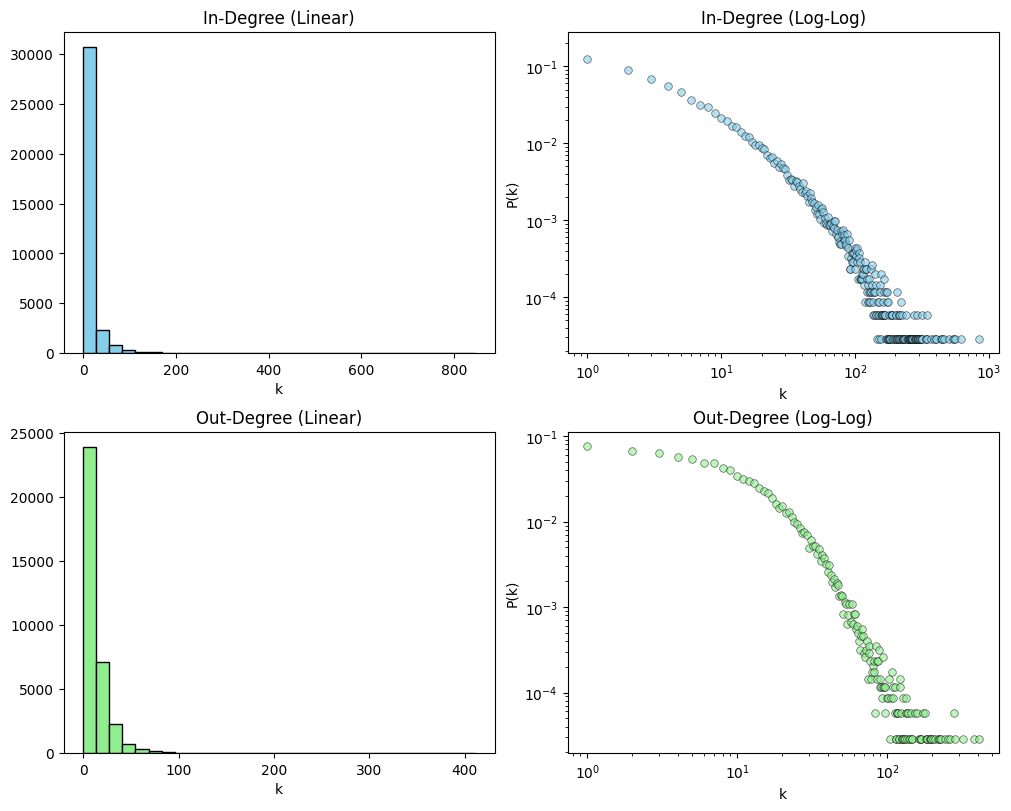

In [3]:
import matplotlib.pyplot as plt
from collections import Counter

# 1. Preparação
def get_dist(deg):
    x, y = zip(*sorted(Counter(deg).items()))
    return x, [v/V for v in y]

k_in, pk_in = get_dist(indegrees)
k_out, pk_out = get_dist(outdegrees)

# 2. Plotagem Direta
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
cfg = [(indegrees, 'In', 'Linear', 'skyblue'), (k_in, 'In', 'Log-Log', 'skyblue'),
       (outdegrees, 'Out', 'Linear', 'lightgreen'), (k_out, 'Out', 'Log-Log', 'lightgreen')]

for i, (data, label, mode, c) in enumerate(cfg):
    ax = axes.flat[i]
    if mode == 'Linear':
        ax.hist(data, bins=30, color=c, edgecolor='black')
    else:
        ax.scatter(data, pk_in if 'In' in label else pk_out, s=30, color=c, alpha=0.6, edgecolor='black', linewidth=0.5)
        ax.set(xscale='log', yscale='log', ylabel='P(k)')
    ax.set(title=f"{label}-Degree ({mode})", xlabel='k')

plt.show()

In [4]:
import powerlaw

# 1. Ajuste da Lei de Potência
# A variável 'indegrees' já está carregada no kernel dos passos anteriores
fit = powerlaw.Fit(indegrees, xmin=None, discrete=True, verbose=False)

# 2. Extração dos Novos Parâmetros
gamma = fit.power_law.alpha
xmin = fit.xmin

# 4. Impressão dos Resultados Atualizados
print("--- Ajuste da Lei de Potência: In-Degrees ---")
print(f"Expoente Gamma (Alpha): {gamma:.4f}")
print("Valor de referencia Gamma: 3.03")
print(f"Valor xmin: {xmin}")


# 2. Ajuste da Lei de Potência para Out-Degrees
# A variável 'outdegrees' já está carregada no kernel dos passos anteriores
fit = powerlaw.Fit(outdegrees, xmin=None, discrete=True, verbose=False)

# 3. Extração dos Novos Parâmetros para Out-Degrees
gamma = fit.power_law.alpha
xmin = fit.xmin

# 5. Impressão dos Resultados Atualizados para Out-Degrees
print("\n--- Ajuste da Lei de Potência: Out-Degrees ---")
print(f"Expoente Gamma (Alpha): {gamma:.4f}")
print("Valor de referencia Gamma: 4.00")
print(f"Valor xmin: {xmin}")

--- Ajuste da Lei de Potência: In-Degrees ---
Expoente Gamma (Alpha): 2.6826
Valor de referencia Gamma: 3.03
Valor xmin: 34.0

--- Ajuste da Lei de Potência: Out-Degrees ---
Expoente Gamma (Alpha): 2.9469
Valor de referencia Gamma: 4.00
Valor xmin: 18.0
